In [1]:
"""
Main objective: Get tables from duckdb and return them as polars DataFrames.
1) prompt user to input DB_PATH, by default "../../data/warehouse/london_bikes.db"
2) run and display table names in the database, prompt user to select by number (multiple allowed)
3) return a dict of polars DataFrames keyed by derived variable names
"""


import duckdb
import os
import polars as pl

def get_db_table(db_path: str = None):

    
    # 1) Handle DB_PATH input
    default_path = "../../data/warehouse/london_bikes.db"
    user_path = input(f"Enter DB_PATH [Default: {default_path}]: ").strip()
    db_path = user_path if user_path else default_path

    if not os.path.exists(db_path):
        print(f"Error: Database file not found at {db_path}")
        return None

    con = duckdb.connect(db_path, read_only=True)

    try:
        # 2) Display tables with numbers
        print("\nAvailable tables in database:")
        query = """
            SELECT table_schema, table_name 
            FROM information_schema.tables 
            WHERE table_schema NOT IN ('information_schema', 'pg_catalog') 
            ORDER BY table_schema, table_name
        """
        tables = con.execute(query).fetchall()
        
        if not tables:
            print("No tables found in this database.")
            return None
            
        for idx, (schema, t_name) in enumerate(tables):
            display_name = f"{schema}.{t_name}" if schema != 'main' else t_name
            print(f"{idx + 1}. {display_name}")

        raw_input = input("\nEnter table numbers to load (e.g. 1,3 or 1-3 or 'all'): ").strip()

        # Parse selection
        table_info = [(s, t) for s, t in tables]
        selected_tables = []

        if raw_input.lower() == 'all':
            selected_tables = table_info
        else:
            selected_indices = set()
            for part in raw_input.split(','):
                part = part.strip()
                if '-' in part:
                    start, end = part.split('-')
                    selected_indices.update(range(int(start) - 1, int(end)))
                else:
                    selected_indices.add(int(part) - 1)
            
            for i in sorted(selected_indices):
                if 0 <= i < len(table_info):
                    selected_tables.append(table_info[i])
                else:
                    print(f"Warning: index {i + 1} out of range, skipping.")

        # 3) Load tables and derive variable names
        def derive_var_name(table_name: str) -> str:
            """Convert table name to a DataFrame variable name, e.g. dim_station -> station_df"""
            prefixes = ['dim_', 'fact_', 'stg_', 'staging_']
            name = table_name.lower()
            for prefix in prefixes:
                if name.startswith(prefix):
                    name = name[len(prefix):]
                    break
            return f"{name}_df"

        result = {}
        for schema, table_name in selected_tables:
            var_name = derive_var_name(table_name)
            if schema != 'main':
                var_name = f"{schema}_{var_name}"
            
            df = con.execute(f'SELECT * FROM "{schema}"."{table_name}"').pl()
            result[var_name] = df
            
            display_name = f"{schema}.{table_name}" if schema != 'main' else table_name
            print(f"Loaded '{display_name}' as '{var_name}' with {len(df)} rows.")

        return result

    except Exception as e:
        print(f"An error occurred: {e}")
        return None
    finally:
        con.close()


if __name__ == "__main__":
    dataframes = get_db_table()
    if dataframes:
        for var_name, df in dataframes.items():
            print(f"\n--- {var_name} ---")
            print(df.head())


Available tables in database:
1. london_bicycles.cycle_hire
2. london_bicycles.cycle_stations
3. london_bicycles.dim_date
4. london_bicycles.stg_cycle_hire
5. london_bicycles.stg_cycle_station
6. london_bicycles_star.dim_bike
7. london_bicycles_star.fact_bike_daily_usage
8. london_bicycles_star.fact_hire
9. london_bicycles_star.next_gen_station_table
10. dim_bike
11. dim_date
12. dim_station
13. fact_hire
Loaded 'london_bicycles_star.next_gen_station_table' as 'london_bicycles_star_next_gen_station_table_df' with 1648 rows.

--- london_bicycles_star_next_gen_station_table_df ---
shape: (5, 4)
┌─────────────────────────────────┬────────────┬─────────────────────────────────┬───────────────┐
│ station_key                     ┆ station_id ┆ station_name                    ┆ id_generation │
│ ---                             ┆ ---        ┆ ---                             ┆ ---           │
│ str                             ┆ i64        ┆ str                             ┆ str           │
╞══

Generating Histogram Plot...


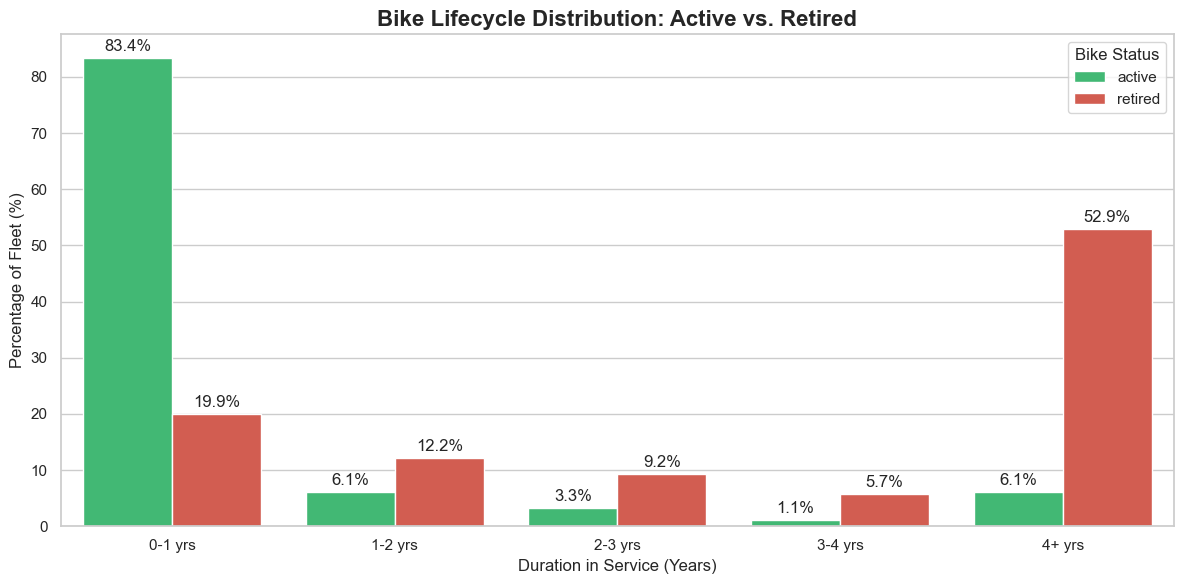


RESULT 3 — Duration Histogram Data
shape: (10, 4)
┌─────────┬──────────────┬────────────┬──────────────┐
│ status  ┆ duration_bin ┆ bike_count ┆ pct_of_group │
│ ---     ┆ ---          ┆ ---        ┆ ---          │
│ str     ┆ str          ┆ i64        ┆ f64          │
╞═════════╪══════════════╪════════════╪══════════════╡
│ active  ┆ 0-1 yrs      ┆ 8691       ┆ 83.39        │
│ active  ┆ 1-2 yrs      ┆ 639        ┆ 6.13         │
│ active  ┆ 2-3 yrs      ┆ 340        ┆ 3.26         │
│ active  ┆ 3-4 yrs      ┆ 112        ┆ 1.07         │
│ active  ┆ 4+ yrs       ┆ 640        ┆ 6.14         │
│ retired ┆ 0-1 yrs      ┆ 4289       ┆ 19.94        │
│ retired ┆ 1-2 yrs      ┆ 2616       ┆ 12.16        │
│ retired ┆ 2-3 yrs      ┆ 1990       ┆ 9.25         │
│ retired ┆ 3-4 yrs      ┆ 1226       ┆ 5.7          │
│ retired ┆ 4+ yrs       ┆ 11386      ┆ 52.94        │
└─────────┴──────────────┴────────────┴──────────────┘


In [2]:
"""
Compare the full-service duration of RETIRED bikes against the
Current in-service duration of ACTIVE bikes to understand where
each active bike sits within its expected lifecycle.
"""

import duckdb
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

# Database connection
db_path = "../../data/warehouse/london_bikes.db"
con = duckdb.connect(db_path, read_only=True)

query = """
-- ================================================================
-- STEP 1: Compute the global latest end date across ALL records
-- ================================================================
WITH global_max AS (
    SELECT MAX(end_date) AS latest_end_date
    FROM london_bicycles_star.fact_hire
),

-- ================================================================
-- STEP 2: Aggregate hire stats per bike
-- ================================================================
bike_hire_stats AS (
    SELECT
        bike_id,
        MIN(start_date) AS first_hire_date,
        MAX(end_date)   AS last_hire_date
    FROM london_bicycles_star.fact_hire
    GROUP BY bike_id
),

-- ================================================================
-- STEP 3: Classify status and calculate duration in decimal years
-- ================================================================
bike_durations AS (
    SELECT
        b.bike_id,
        b.first_hire_date,
        b.last_hire_date,
        g.latest_end_date,
        CASE
            WHEN b.last_hire_date < g.latest_end_date - INTERVAL '2 weeks'
                THEN 'retired'
            ELSE 'active'
        END AS status,
        CASE
            WHEN b.last_hire_date < g.latest_end_date - INTERVAL '2 weeks'
                THEN EXTRACT(epoch FROM (b.last_hire_date - b.first_hire_date)) / 31557600
            ELSE
                EXTRACT(epoch FROM (g.latest_end_date - b.first_hire_date)) / 31557600
        END AS duration_years
    FROM bike_hire_stats b
    CROSS JOIN global_max g
),

-- ================================================================
-- STEP 4: Assign histogram bins and numeric bin order
-- ================================================================
bike_bins AS (
    SELECT
        bike_id,
        status,
        duration_years,
        CASE
            WHEN duration_years < 1 THEN '0-1 yrs'
            WHEN duration_years < 2 THEN '1-2 yrs'
            WHEN duration_years < 3 THEN '2-3 yrs'
            WHEN duration_years < 4 THEN '3-4 yrs'
            ELSE '4+ yrs'
        END AS duration_bin,
        CASE
            WHEN duration_years < 1 THEN 1
            WHEN duration_years < 2 THEN 2
            WHEN duration_years < 3 THEN 3
            WHEN duration_years < 4 THEN 4
            ELSE 5
        END AS bin_order
    FROM bike_durations
),

-- ================================================================
-- STEP 5: Aggregate descriptive statistics
-- ================================================================
agg_stats AS (
    SELECT
        status,
        ROUND(AVG(duration_years),    4) AS avg_duration_years,
        ROUND(MEDIAN(duration_years), 4) AS median_duration_years,
        ROUND(MIN(duration_years),    4) AS min_duration_years,
        ROUND(MAX(duration_years),    4) AS max_duration_years,
        COUNT(*)                         AS bike_count
    FROM bike_durations
    GROUP BY status
),

-- ================================================================
-- STEP 6: Build histogram percentages
-- ================================================================
histogram AS (
    SELECT
        b.status,
        b.duration_bin,
        b.bin_order,
        COUNT(*) AS bike_count,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (PARTITION BY b.status), 2) AS pct_of_group
    FROM bike_bins b
    GROUP BY b.status, b.duration_bin, b.bin_order
),

-- ================================================================
-- FINAL UNION: Combine detail, summary, and histogram
-- ================================================================
combined_results AS (
    SELECT
        'detail' AS result_type, 1 AS section_id, bike_id::VARCHAR AS bike_id, 
        first_hire_date::VARCHAR AS first_hire_date, last_hire_date::VARCHAR AS last_hire_date, 
        status, ROUND(duration_years, 4) AS duration_years, NULL::VARCHAR AS duration_bin,
        NULL::DOUBLE AS avg_duration_years, NULL::DOUBLE AS median_duration_years,
        NULL::DOUBLE AS min_duration_years, NULL::DOUBLE AS max_duration_years,
        NULL::BIGINT AS bike_count, NULL::DOUBLE AS pct_of_group, 
        bike_id::BIGINT AS sub_sort
    FROM bike_durations

    UNION ALL

    SELECT
        'summary', 2, NULL, NULL, NULL, status, NULL, NULL,
        avg_duration_years, median_duration_years, min_duration_years, max_duration_years,
        bike_count, NULL, 0
    FROM agg_stats

    UNION ALL

    SELECT
        'histogram', 3, NULL, NULL, NULL, status, NULL, duration_bin,
        NULL, NULL, NULL, NULL, bike_count, pct_of_group,
        bin_order
    FROM histogram
)
SELECT * FROM combined_results
ORDER BY section_id, status ASC, sub_sort ASC
"""

# Execute and convert to Polars
full_df = con.execute(query).pl()

# ----------------------------------------------------------------
# Split the DataFrame into focused result sets
# ----------------------------------------------------------------

detail_df = full_df.filter(pl.col("result_type") == "detail").select(["bike_id", "status", "duration_years"])
summary_df = full_df.filter(pl.col("result_type") == "summary").select(["status", "avg_duration_years", "bike_count"])
histogram_df = full_df.filter(pl.col("result_type") == "histogram").select(["status", "duration_bin", "bike_count", "pct_of_group"])

# ----------------------------------------------------------------
# VISUALIZATION: Result 3 — Duration Histogram by Status
# ----------------------------------------------------------------
print("Generating Histogram Plot...")

# Convert Polars to Pandas for Seaborn compatibility
plot_data = histogram_df.to_pandas()

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Create a grouped bar chart
ax = sns.barplot(
    data=plot_data, 
    x="duration_bin", 
    y="pct_of_group", 
    hue="status",
    palette={"active": "#2ecc71", "retired": "#e74c3c"}
)

# Add labels and formatting
plt.title("Bike Lifecycle Distribution: Active vs. Retired", fontsize=16, fontweight='bold')
plt.xlabel("Duration in Service (Years)", fontsize=12)
plt.ylabel("Percentage of Fleet (%)", fontsize=12)
plt.legend(title="Bike Status")

# Add percentage labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.tight_layout()
plt.show()

# Print text results for verification
print("\n" + "=" * 60)
print("RESULT 3 — Duration Histogram Data")
print("=" * 60)
print(histogram_df)